In [ ]:
# PART 1: PYTORCH - FROM SCRATCH TO FRAMEWORK
#
# WHAT THIS CELL DOES:
#   Move from our homemade Tensor/DataLoader-style loops to PyTorch's tools.
#   1) Load MNIST (same digits as before)
#   2) Convert arrays → torch.Tensor
#   3) Wrap them in DataLoader so training gets neat mini-batches
#
# WHY DataLoader?
#   Instead of hand-slicing X[start:end], PyTorch gives you:
#     for xb, yb in train_loader: ...
#   with shuffling, batching, and later easy GPU/multi-worker support.

# PyTorch Basics and the MNIST DataLoader

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_openml

# --- 1) Load MNIST: 70,000 images, each 28×28 = 784 pixels ---
print("Loading MNIST...")
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, parser='auto')

# OpenML often returns pandas; use NumPy to avoid KeyError on label indexing
X = np.asarray(X, dtype=np.float32) / 255.0  # pixels → [0, 1]
y = np.asarray(y, dtype=np.int64)            # digit labels 0–9

# --- 2) Train/test split (80% / 20%) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# X_train ≈ (56000, 784), X_test ≈ (14000, 784)

# --- 3) NumPy → PyTorch tensors (same numbers, framework-native type) ---
X_train_t = torch.from_numpy(X_train)
y_train_t = torch.from_numpy(y_train)
X_test_t = torch.from_numpy(X_test)
y_test_t = torch.from_numpy(y_test)

# --- 4) Dataset = pairing (image, label); DataLoader = batch iterator ---
train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

batch_size = 64  # how many images per training step
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)   # shuffle each epoch
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)  # no need to shuffle eval

# Expected prints (with 56k train / 14k test and batch_size=64):
#   Training batches: 875   because 56000/64 = 875
#   Test batches:     219   because 14000/64 ≈ 218.75 → 219 (last batch smaller)
print(f"Training batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Loading MNIST...
Training batches: 875
Test batches: 219


In [4]:
# Build the Same 2-Layer MLP in PyTorch
#
# WHAT THIS IS:
#   Same idea as yesterday's TwoLayerNet, but using torch.nn instead of our homemade
#   Linear / ReLU / Tensor classes.
#
#   Architecture (layers = processing stages, not data splits):
#     784 pixels → Linear(fc1) → ReLU → Linear(fc2) → 10 logits (digit scores)
#
# COMPARE TO OUR FRAMEWORK:
#   nn.Module          ≈ our Module
#   nn.Linear          ≈ our Linear (W @ x + b, with autograd built-in)
#   nn.ReLU            ≈ our ReLU
#   model.forward(x)   ≈ stacking layers / Sequential
#   return logits      ≈ no softmax here; nn.CrossEntropyLoss does it later

class TwoLayerNet(nn.Module):
    def __init__(self, input_size=784, hidden_size=128, output_size=10):
        super().__init__()  # required: sets up PyTorch Module internals
        # Learnable layers (weights + biases created automatically)
        self.fc1 = nn.Linear(input_size, hidden_size)   # 784 → 128
        self.relu = nn.ReLU()                           # nonlinearity
        self.fc2 = nn.Linear(hidden_size, output_size)  # 128 → 10

        # He / Kaiming init: good default when using ReLU (like our * sqrt(2/in))
        nn.init.kaiming_normal_(self.fc1.weight, nonlinearity='relu')
        nn.init.kaiming_normal_(self.fc2.weight, nonlinearity='linear')

    def forward(self, x):
        # x shape: (batch, 784)
        x = self.fc1(x)    # → (batch, 128)
        x = self.relu(x)   # zeros out negatives
        x = self.fc2(x)    # → (batch, 10) raw scores
        return x           # logits (NOT probabilities yet)


model = TwoLayerNet()
print(model)
# Expected print: shows the layer stack fc1 → ReLU → fc2 with shapes
#   Linear(in=784, out=128), ReLU(), Linear(in=128, out=10) 


TwoLayerNet(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


Epoch  1: Loss = 0.2346, Acc: 0.9283, LR:0.097553
Epoch  2: Loss = 0.1051, Acc: 0.9676, LR:0.090451
Epoch  3: Loss = 0.0739, Acc: 0.9766, LR:0.079389
Epoch  4: Loss = 0.0503, Acc: 0.9838, LR:0.065451
Epoch  5: Loss = 0.0327, Acc: 0.9898, LR:0.050000
Epoch  6: Loss = 0.0202, Acc: 0.9940, LR:0.034549
Epoch  7: Loss = 0.0128, Acc: 0.9969, LR:0.020611
Epoch  8: Loss = 0.0088, Acc: 0.9986, LR:0.009549
Epoch  9: Loss = 0.0072, Acc: 0.9991, LR:0.002447
Epoch 10: Loss = 0.0064, Acc: 0.9994, LR:0.000000


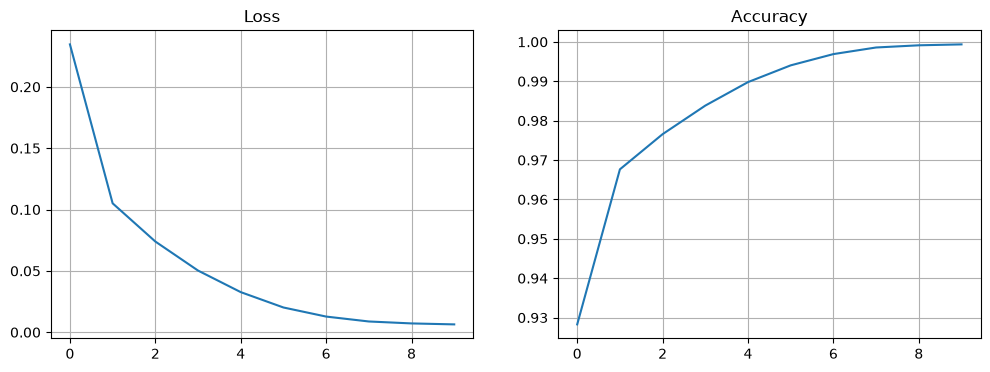

In [7]:
# Training Loop with PyTorch (SGD + LR Schedule)
#
# WHAT THIS CELL DOES:
#   Train TwoLayerNet on MNIST the "real PyTorch way":
#     forward → loss → zero_grad → backward → optimizer.step → (optional) LR schedule
#   Same recipe as our homemade loop, but PyTorch handles grads + GPU for us.
#
# NEW PIECES:
#   device          → 'cuda' if GPU exists, else 'cpu'
#   CrossEntropyLoss → combines softmax + negative-log of true class
#   SGD+momentum    → like our Momentum optimizer
#   CosineAnnealingLR → slowly lowers learning rate over epochs (often helps finish training)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = TwoLayerNet().to(device)  # move weights to GPU/CPU

loss_fn = nn.CrossEntropyLoss()  # expects logits + integer labels (0–9)
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9)
# Cosine schedule: LR starts at 0.1 and anneals toward ~0 over T_max epochs
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

epochs = 10
train_losses, train_accs = [], []

for epoch in range(epochs):
    model.train()  # dropout/batchnorm behave in "train mode" (good habit)
    running_loss, correct, total = 0.0, 0, 0

    for X_batch, y_batch in train_loader:  # each batch ≈ 64 images
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        # 1) Forward: raw digit scores
        logits = model(X_batch)          # same as model.forward(X_batch)
        loss = loss_fn(logits, y_batch)  # "how wrong?" (one number)

        # 2) Backward + update (classic 3 lines)
        optimizer.zero_grad()  # clear old .grad
        loss.backward()        # fill .grad on all parameters
        optimizer.step()       # weights -= (momentum SGD step)

        # 3) Track stats for this epoch
        running_loss += loss.item() * X_batch.size(0)
        _, pred = torch.max(logits, 1)  # predicted digit = argmax over 10 logits
        correct += (pred == y_batch).sum().item()
        total += y_batch.size(0)

    scheduler.step()  # update LR for next epoch
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)
    # Expect: Loss ↓, Acc ↑, LR slowly ↓ each epoch
    print(
        f"Epoch {epoch+1:2d}: Loss = {epoch_loss:.4f}, "
        f"Acc = {epoch_acc:.4f}, LR = {scheduler.get_last_lr()[0]:.6f}"
    )

# Plots: left = loss falling, right = accuracy rising
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses); ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.grid(True)
ax2.plot(train_accs); ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch'); ax2.grid(True)
plt.show()


Training ImprovedMLP (BatchNorm + Dropout + Adam)...
  Epoch  1: Loss=0.3173, Train Acc=0.9140
  Epoch  2: Loss=0.1654, Train Acc=0.9523
  Epoch  3: Loss=0.1279, Train Acc=0.9620
  Epoch  4: Loss=0.1090, Train Acc=0.9664
  Epoch  5: Loss=0.0951, Train Acc=0.9705
  Epoch  6: Loss=0.0836, Train Acc=0.9737
  Epoch  7: Loss=0.0751, Train Acc=0.9758
  Epoch  8: Loss=0.0692, Train Acc=0.9776
  Epoch  9: Loss=0.0656, Train Acc=0.9792
  Epoch 10: Loss=0.0616, Train Acc=0.9804

ImprovedMLP Test Accuracy: 0.9749
TwoLayerNet (earlier SGD) Test Accuracy: 0.9780

Comparison:
  Baseline TwoLayerNet: 0.9780
  ImprovedMLP:          0.9749
  (Improved often generalizes a bit better / trains more stably;
   exact winner can vary with seed and epochs.)


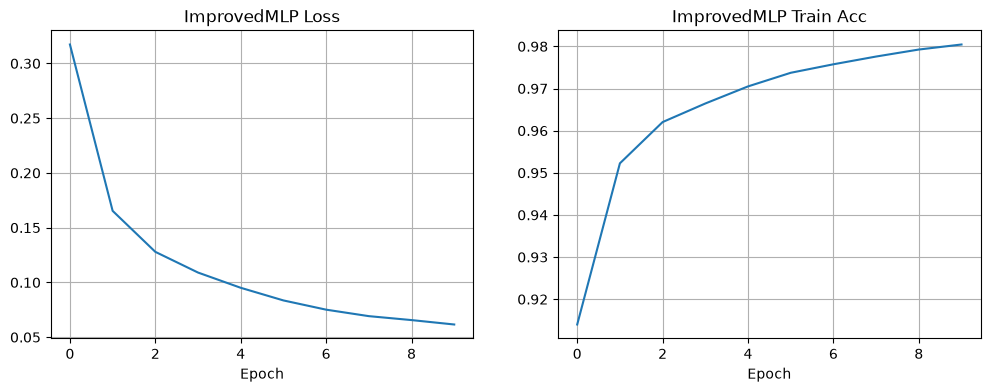

In [ ]:
# Add Dropout + BatchNorm and Compare
#
# WHAT WE'RE ADDING (same ideas as Part 6 in the mini-framework notebook):
#   BatchNorm1d - keep hidden activations well-scaled (mean~0, var~1), then learn scale/shift
#   Dropout     - during training, randomly zero some hidden units (here 20%) to reduce overfitting
#
# FLOW:
#   x → Linear → BatchNorm → ReLU → Dropout → Linear → logits
#
# IMPORTANT:
#   model.train()  → dropout ON, batchnorm uses batch stats
#   model.eval()   → dropout OFF, batchnorm uses running stats
#   Forgetting eval() makes test accuracy look randomly worse.

class ImprovedMLP(nn.Module):
    def __init__(self, input_size=784, hidden_size=128, output_size=10, dropout=0.2):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.bn1 = nn.BatchNorm1d(hidden_size)  # normalize across the batch, per feature
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)      # p=0.2 → drop ~20% of hidden units while training
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout(x)  # no-op in eval mode
        x = self.fc2(x)
        return x  # logits


def evaluate(model, loader, device):
    """Test accuracy with dropout OFF / batchnorm in eval mode."""
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():  # no grads needed for testing (faster, less memory)
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            pred = logits.argmax(dim=1)
            correct += (pred == y_batch).sum().item()
            total += y_batch.size(0)
    return correct / total


def train_model(model, optimizer, epochs=10):
    """Standard PyTorch train loop; returns loss/acc histories."""
    loss_fn = nn.CrossEntropyLoss()
    losses, accs = [], []
    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            loss = loss_fn(logits, y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * X_batch.size(0)
            pred = logits.argmax(dim=1)
            correct += (pred == y_batch).sum().item()
            total += y_batch.size(0)
        losses.append(running_loss / total)
        accs.append(correct / total)
        print(f"  Epoch {epoch+1:2d}: Loss={losses[-1]:.4f}, Train Acc={accs[-1]:.4f}")
    return losses, accs


# --- Train improved model (BatchNorm + Dropout + Adam) ---
print("Training ImprovedMLP (BatchNorm + Dropout + Adam)...")
model_bn = ImprovedMLP().to(device)
optimizer_bn = optim.Adam(model_bn.parameters(), lr=0.001)
bn_losses, bn_accs = train_model(model_bn, optimizer_bn, epochs=10)

test_acc_bn = evaluate(model_bn, test_loader, device)
print(f"\nImprovedMLP Test Accuracy: {test_acc_bn:.4f}")

# Compare to the plain TwoLayerNet trained earlier (SGD), if it exists
if 'model' in dir() and isinstance(model, TwoLayerNet):
    test_acc_base = evaluate(model, test_loader, device)
    print(f"TwoLayerNet (earlier SGD) Test Accuracy: {test_acc_base:.4f}")
    print("\nComparison:")
    print(f"  Baseline TwoLayerNet: {test_acc_base:.4f}")
    print(f"  ImprovedMLP:          {test_acc_bn:.4f}")
    print("  (Improved often generalizes a bit better / trains more stably;")
    print("   exact winner can vary with seed and epochs.)")
else:
    print("(Run the earlier TwoLayerNet training cell first for a side-by-side compare.)")

# Plots for the improved model
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(bn_losses); ax1.set_title('ImprovedMLP Loss'); ax1.set_xlabel('Epoch'); ax1.grid(True)
ax2.plot(bn_accs); ax2.set_title('ImprovedMLP Train Acc'); ax2.set_xlabel('Epoch'); ax2.grid(True)
plt.show()

# Observation: BatchNorm + Dropout usually gives higher test accuracy and faster convergence. 
# This is what you'll use in production models.

In [10]:
"""
The journey of one digit picture

pixels → Linear → BatchNorm → ReLU → Dropout → Linear → logits

Imagine a blurry photo of a handwritten 7.  
We flatten it into 784 numbers (brightness of each pixel). Those numbers walk through a pipeline:

---

1. `pixels` (784 numbers) 
(picture elements - Smallest dots in the image. MNIST: 28×28 = 784 brightness values (0–1 after scaling).)

Raw ingredients: “how dark is each spot?”

---

2. `Linear` (first mix) 
(also called FC / Dense - Linear layer / Fully Connected layer - Meaning: Every input connects to every output.
Weights (W): how much each input matters
Bias (b): baseline offset
Here: first Linear = 784→128; last Linear = 128→10)

Mixes all pixels together with learned knobs (weights).

```
784 messy pixel values  →  128 new “summary signals”
```

Like: “Does this look curvy? tall? open on the right?”  
At the start the knobs are almost random; training tunes them.

---

3. `BatchNorm` 
(Batch Normalization - Meaning: For each mini-batch, normalize features to roughly mean 0 / variance 1, then allow learnable rescale
Why: keeps signal scales stable so deeper/faster training is easier)

Rescales those 128 signals so theyre not crazy huge or tiny.

```
too wild / too weak  →  nicer, standard-sized signals
```

Helps the next steps learn without the “volume” going haywire.

---

4. `ReLU` 
(Rectified Linear Unit - Meaning: Activation function, Why: adds nonlinearity (without it, stacked Linears collapse to one Linear) )

A simple filter:

```
if signal < 0  → set to 0
if signal > 0  → keep it
```

Throws away “negative noise,” keeps useful positive evidence.  
This is what lets the net learn curves, not only straight-line rules.

---

5. `Dropout` (training only) 
(Meaning: During training, randomly set some activations to 0 (e.g. 20%).
Why: regularization - reduces overfitting by not relying on a few neurons
At test: usually off (model.eval()))

Randomly silences ~20% of those signals each practice round.

```
team practice with random players benched
```

So the model cant cheat by relying on one lucky neuron.  
On the real test (`eval`), everyone plays - dropout is off.

---

6. `Linear` (second mix)
Takes the 128 cleaned signals and makes 10 scores:

```
score for 0, score for 1, ... score for 9
```

Highest score ≈ the models best guess.

---

7. `logits` 
(0ften treated as “log-odds” scores (in practice: raw unnormalized class scores)
Meaning: the 10 numbers before softmax/probabilities)

Those 10 raw scores before turning them into nice probabilities.

Later, `CrossEntropyLoss` does the “softmax + how wrong am I?” part using these logits.

---

Whole path in one glance
```
photo pixels
   ↓ mix (Linear)
128 ideas
   ↓ normalize (BatchNorm)
   ↓ keep positives (ReLU)
   ↓ random practice drops (Dropout)
   ↓ mix again (Linear)
10 digit scores (logits)
   ↓ (loss / argmax)
“I think it's a 7”
```

One-liner for an easy explanation: the image gets mixed, cleaned up, sparsified for practice, then scored into “which digit?” - 
and training keeps adjusting the mixers until the scores match the true digit.

Extra terms around this:

Term	        Full form	                            Meaning
MLP         Multi-Layer Perceptron          Stack of Linear layers + activations

NN	        Neural Network	                Model made of layered neuron-like units

SGD	        Stochastic Gradient Descent	    Update weights using grads from mini-batches

Adam	    Adaptive Moment Estimation	    Optimizer that adapts step size per weight

CE-Cross-Entropy	Cross-Entropy loss      Punishes wrong class probabilities

Epoch      (not an acronym)                 One full pass through training data

Batch	        mini-batch                  Small group of examples per update (e.g. 64)

Autograd	    Automatic Differentiation    Auto-computes gradients for backward

One-line story
Pixels enter → Linear mixes them → BatchNorm stabilizes scale → ReLU keeps useful positive signals → Dropout randomly practices without some neurons → 
Linear scores digits → logits are those raw scores used for loss/prediction.

pixels → Linear → BatchNorm → ReLU → Dropout → Linear → logits
                                                      ↓
                                    ┌─────────────────┴─────────────────┐
                                    │                                   │
                              during TRAINING                     during PREDICTION
                                    │                                   │
                         CrossEntropyLoss                      argmax(logits)
                         (softmax inside)                      → predicted digit
                                    │
                              loss number → backward → update weights

Softmax — “turn scores into probabilities”
Meaning: Convert 10 logits into 10 numbers that:
are all between 0 and 1
sum to 1 (like a probability pie)

Example:
Digit	Logit	After softmax
0	    1.0	        0.05
…	    …	        …
…	    …	        …
7	    5.0	        0.70
So the model says “~70% chance its a 7.”

In your PyTorch code, you usually dont call softmax yourself for training, because:

nn.CrossEntropyLoss()
does softmax + cross-entropy internally from logits.

Where it comes in: right after logits, inside the loss, during training (and if you want probabilities for display).

Argmax — “pick the winner”
Full form: Argument of the maximum (index of the biggest value)
Meaning: Look at the 10 scores and choose the digit with the highest number.

logits = [0.1, 0.0, 2.0, ..., 5.5, ...]
argmax → 7   (if 5.5 was largest at position 7)
No probabilities needed — just “who scored highest?”

Where it comes in: after logits, when you want a hard prediction for accuracy:
pred = logits.argmax(dim=1)  # or torch.max(logits, 1)

Softmax vs Argmax (simple)
                    Softmax	                    Argmax
Output	      10 probabilities	            1 class index
Use	          training loss, “how sure?”	“whats the answer?”
In your flow  inside CrossEntropyLoss        when computing accuracy / showing Pred

They often agree: the digit with the biggest logit is also the digit with the biggest softmax probability.
"""

"\nThe journey of one digit picture\n\npixels → Linear → BatchNorm → ReLU → Dropout → Linear → logits\n\nImagine a blurry photo of a handwritten 7.  \nWe flatten it into 784 numbers (brightness of each pixel). Those numbers walk through a pipeline:\n\n---\n\n1. `pixels` (784 numbers) \n(picture elements - Smallest dots in the image. MNIST: 28×28 = 784 brightness values (0–1 after scaling).)\n\nRaw ingredients: “how dark is each spot?”\n\n---\n\n2. `Linear` (first mix) \n(also called FC / Dense - Linear layer / Fully Connected layer - Meaning: Every input connects to every output.\nWeights (W): how much each input matters\nBias (b): baseline offset\nHere: first Linear = 784→128; last Linear = 128→10)\n\nMixes all pixels together with learned knobs (weights).\n\n```\n784 messy pixel values  →  128 new “summary signals”\n```\n\nLike: “Does this look curvy? tall? open on the right?”  \nAt the start the knobs are almost random; training tunes them.\n\n---\n\n3. `BatchNorm` \n(Batch Normaliz

In [11]:
# PART 2: JAX — FUNCTIONAL DEEP LEARNING
#
# HOW JAX DIFFERS FROM PYTORCH (big picture):
#   PyTorch: model is an object with weights inside; loss.backward() fills .grad
#   JAX:     weights are plain arrays you PASS INTO pure functions;
#            grad(f) builds a new function that returns gradients
#
# Three superpowers you'll see everywhere in JAX:
#   grad  — automatic differentiation (like loss.backward, but functional)
#   jit   — compile the function to run faster (XLA)
#   vmap  — auto-batch: write code for 1 example, run on a batch

# JAX Basics and vmap, grad, jit

import jax
import jax.numpy as jnp
from jax import grad, jit, vmap, random
import optax  # JAX optimizer library (Adam, SGD, ...) — used in later cells

# --- Random numbers need an explicit key (JAX is functional / reproducible) ---
key = random.PRNGKey(0)           # seed container
x = random.normal(key, (3,))      # 3 random numbers ~ Normal(0,1)
print("JAX array:", x)

# --- Pure function: same input → same output, no hidden model.state ---
def f(x):
    return jnp.sum(x ** 2)        # f(x) = x0² + x1² + x2²

# grad(f) = derivative of f w.r.t. its input
# For sum(x^2), analytic grad is 2x
grad_f = grad(f)
print("Gradient of x^2 sum:", grad_f(x))  # expect about 2*x

# --- jit: compile once, run fast many times ---
@jit
def g(x):
    return jnp.dot(x, x)  # same as sum(x*x)

print("JIT compiled:", g(x))

# --- vmap: write "one sample" logic, apply to a whole batch ---
def single_predict(params, x):
    # params: weight vector, x: one input vector
    return jnp.dot(x, params)

# in_axes=(None, 0) means:
#   params → do NOT batch (same weights for everyone)
#   x      → batch along axis 0 (each row is one example)
batch_predict = vmap(single_predict, in_axes=(None, 0))

key, k1, k2 = random.split(key, 3)
params = random.normal(k1, (3,))           # fake weights
X_batch = random.normal(k2, (4, 3))        # 4 examples, 3 features each
preds = batch_predict(params, X_batch)     # shape (4,)
print("vmap batch predictions:", preds)
print("shapes: params", params.shape, "| X_batch", X_batch.shape, "| preds", preds.shape)


JAX array: [ 1.6226422   2.0252647  -0.43359444]
Gradient of x^2 sum: [ 3.2452843  4.0505295 -0.8671889]
JIT compiled: 6.922669
